# Beyond Image Classification

## Start with the question: a class label does not say where anything is

Imagine an image containing two vehicles. A classifier can answer whether a vehicle is present, but it cannot by that output alone tell you which pixels belong to either vehicle, where their boxes are, or whether one is partly hidden behind the other.

Many vision tasks require structured predictions: boxes, masks, coordinates, or several object-specific outputs. The input may still be an image tensor, and the backbone may still use convolutional features. What changes is the target, the head, the loss, and the evaluation contract.

This lesson compares those outputs, calculates box and pixel overlap, follows a segmentation loss and update, and traces the exact model in the [code companion](36_Beyond_Image_Classification.ipynb). Its opening rectangle task is a local mechanics example. A second project trains and evaluates on disjoint rectangle/ellipse layouts; neither is an assessment of real-world segmentation.

Review [CNN Architecture and Training](34_CNN_Architecture_and_Training_Notes.ipynb) for the classifier pipeline. Here we keep spatial information because the prediction must identify locations rather than collapse everything into one image label.


<div style="background:#FEF3C7;border-left:6px solid #D97706;padding:14px;border-radius:8px"><b>Two stages in the companion.</b> The existing hand calculations and shape/parameter tables describe the opening mechanics example. The complete project at the end uses a separate model and data protocol, summarized below.</div>


## Match the prediction format to the task

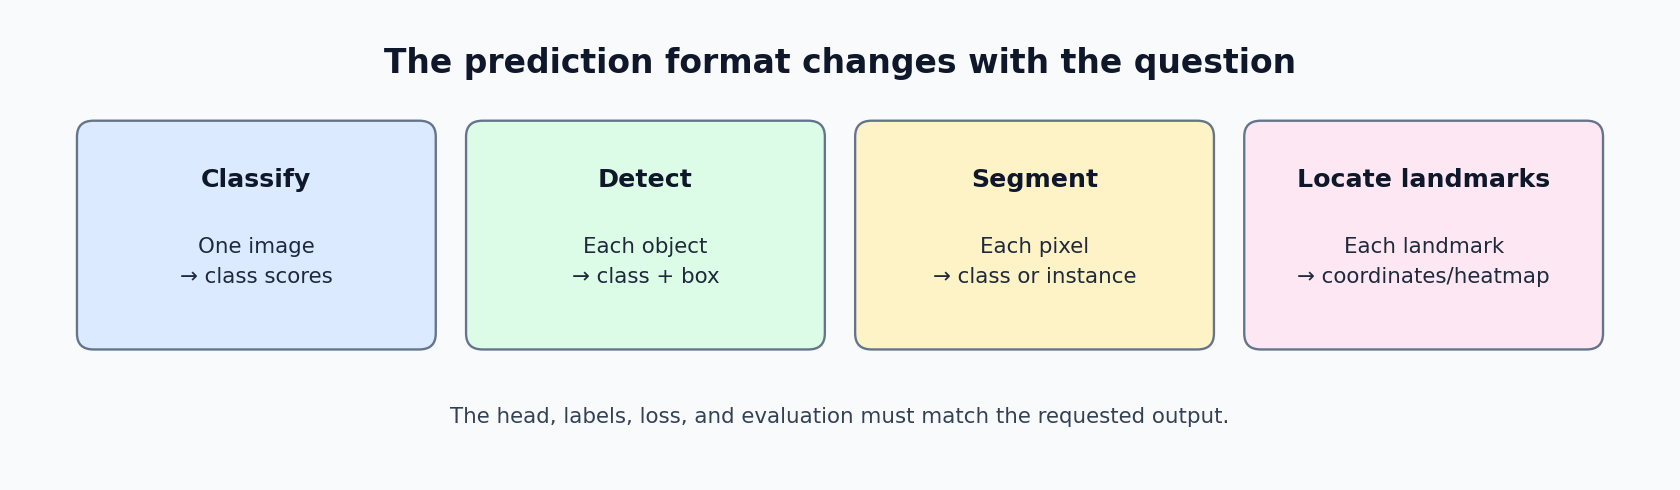

| Task | Output | What the label must specify |
| --- | --- | --- |
| Classification | One or several class scores | Image-level categories |
| Object detection | Classes and bounding boxes | Each object's class and box |
| Semantic segmentation | A class at each valid pixel | Pixel categories |
| Instance segmentation | Separate masks for objects | Object identity and covered pixels |
| Keypoint estimation | Coordinates or heatmaps | Landmark locations and visibility |

Semantic segmentation can label every vehicle pixel as vehicle while still merging the two vehicles at the class level. Instance segmentation separates their identities. A box gives coarse extent, while a mask describes the shape more precisely.

A dense output is not automatically a better answer. Image-level classification may be the correct task if locations do not matter and location labels are unavailable. Choose the target that answers the user's actual question.


## Represent a box with an explicit coordinate convention

Use box coordinates $(x_{min},y_{min},x_{max},y_{max})$ and continuous or half-open extents. Width is $x_{max}-x_{min}$ and height is $y_{max}-y_{min}$ under this convention.

For a target box $A=(1,1,5,5)$ and prediction $B=(3,1,7,5)$, both widths and heights are four, so both areas are sixteen. Their overlap spans x from three to five and y from one to five, giving intersection area eight.

| Quantity | Calculation | Result |
| --- | --- | --- |
| Target area | $4\times4$ | 16 |
| Predicted area | $4\times4$ | 16 |
| Intersection | $2\times4$ | 8 |
| Union | $16+16-8$ | 24 |
| Intersection over union | $8/24$ | 0.333333 |

Coordinate formats must remain consistent through resizing and evaluation. A center/width/height format is not the same array as min/max coordinates. Inclusive integer-pixel conventions can also use different extent arithmetic; do not mix them into this calculation silently.


## Detection needs matching and scores as well as overlap

Intersection over union, or IoU, compares one predicted region with one target. Detection usually has several predictions and several objects, so it also needs a rule assigning predictions to targets, class compatibility, and a confidence ranking.

Suppose two ground-truth objects are present. A simplified evaluation at a chosen overlap threshold finds two correct matched predictions and one unmatched extra prediction. Precision is $2/3$ and recall is $2/2=1$.

| Event | Interpretation |
| --- | --- |
| Correct class and qualifying overlap | Candidate true positive under matching |
| Extra duplicate prediction | False positive if its object is already matched |
| Missed target object | False negative |
| Wrong class | Not a correct match for that class |

Average precision summarizes a precision/recall relationship under a specified detection protocol; it is not simply the mean of box IoUs. Thresholds, class aggregation, and matching conventions must accompany a reported score.

During inference, overlapping predictions may need suppression or another duplicate-handling strategy. This is distinct from learning box coordinates. A high class score alone cannot compensate for an incorrect location or a missing object.


## Semantic masks and instance masks answer different questions

For a binary semantic task, each valid pixel has target zero for background or one for foreground. For a multi-class task, each pixel can hold a class ID, with separately defined ignored or unlabeled pixels.

If two adjacent people belong to the same semantic category, their pixels can share the same class ID. An instance representation additionally distinguishes person one from person two, often through per-object masks and associated classes.

| Representation | Distinguishes class? | Distinguishes objects of one class? |
| --- | --- | --- |
| Image class scores | Yes | No spatial identity |
| Semantic mask | Yes at pixels | Usually no |
| Instance masks | Yes | Yes |
| Bounding boxes | Yes with class labels | Yes through separate predictions |

Encoder/decoder segmentation designs can reduce resolution to learn context and then restore a prediction grid, with skip connections helping retain detail; [U-Net](https://arxiv.org/abs/1505.04597) is a foundational example. Object-based systems can combine detection and instance masks, as in [Mask R-CNN](https://arxiv.org/abs/1703.06870).

The companion uses a simpler same-resolution binary head without a downsampling/upsampling path. It demonstrates pixel predictions, not either full named architecture.


## Calculate pixel IoU and Dice from the same counts

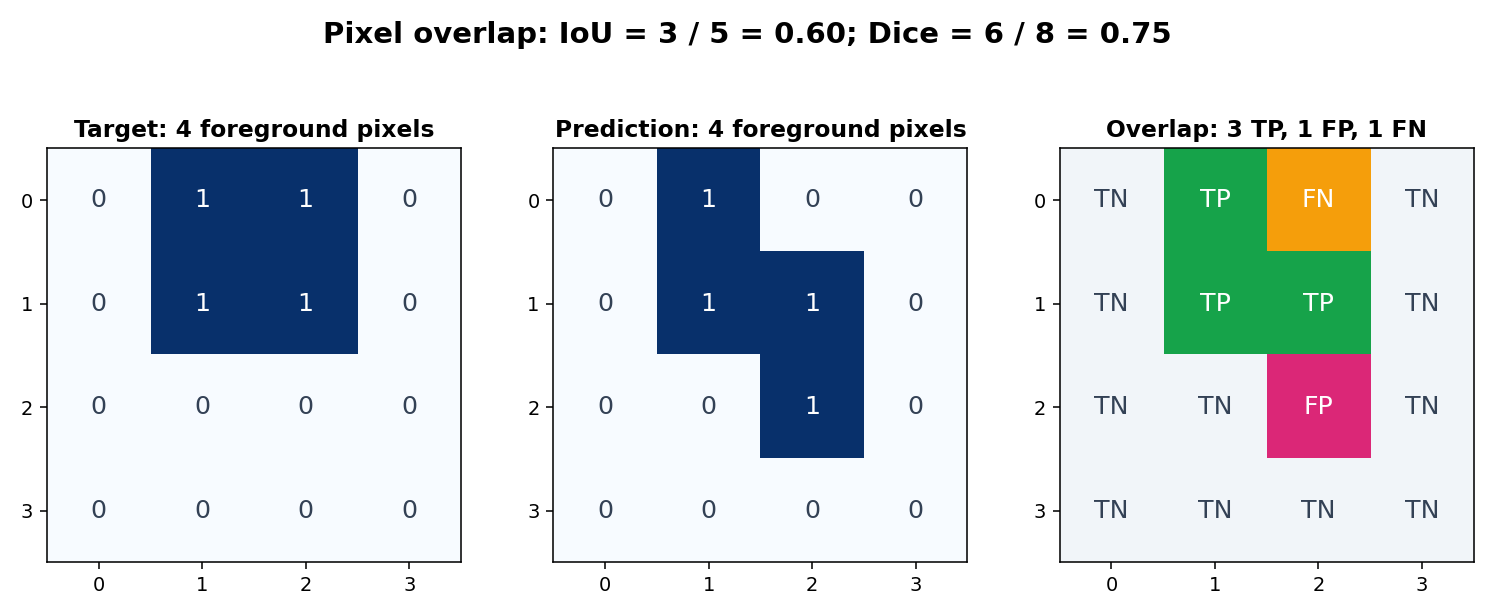

In this teaching example, the target has four foreground pixels and the prediction also has four. Three overlap, so $TP=3$, $FP=1$, $FN=1$, and the remaining eleven pixels are true negatives.

$$IoU=\frac{TP}{TP+FP+FN}=\frac35=0.6,$$
$$Dice=\frac{2TP}{2TP+FP+FN}=\frac68=0.75.$$

| Metric | Result | What it emphasizes |
| --- | --- | --- |
| Pixel accuracy | $(3+11)/16=0.875$ | All correctly labeled pixels |
| Foreground IoU | 0.60 | Overlap relative to union |
| Foreground Dice | 0.75 | Overlap relative to combined foreground size |

An all-background prediction has accuracy $12/16=0.75$ but foreground IoU zero. This explains why background-dominated pixel accuracy can hide a useless foreground prediction.

When both target and prediction are empty, overlap denominators can be zero. Define whether to skip the case, assign a specific convention, or use a chosen smoothing rule. Also state whether counts are accumulated across images or metrics are averaged per image; those weight examples differently.


## Use a pixel loss that matches the output logits

For binary foreground targets, a model can output one logit $z$ per pixel. Sigmoid gives $p=1/(1+e^{-z})$, and binary cross-entropy is:

$$\ell=-y\ln p-(1-y)\ln(1-p).$$

A logits-based implementation performs a stable equivalent calculation without requiring a separate sigmoid before the loss.

| Logit | Target | Probability | Pixel loss |
| --- | --- | --- | --- |
| 0 | 0 | 0.5 | 0.693147 |
| $\ln3$ | 1 | 0.75 | 0.287682 |
| $-\ln3$ | 0 | 0.25 | 0.287682 |
| 0 | 1 | 0.5 | 0.693147 |

The mean over these four pixels is approximately 0.490415. The loss rewards probabilities that fit the labels, while thresholded IoU evaluates a chosen hard mask. They are related measurements, not the same objective.

Multi-class semantic segmentation commonly uses a class-logit vector per pixel with a matching multi-class loss. A single binary foreground logit cannot express several mutually exclusive categories without changing the output contract.


## Follow one pixel gradient and a learning update

For a binary-logit loss, $\partial\ell/\partial z=p-y$. With a foreground target one and current logit zero, the derivative is $0.5-1=-0.5$.

Treat that logit as an adjustable bias for a single teaching pixel. SGD at learning rate 0.1 changes it to 0.05, increasing foreground probability to approximately 0.512497 and reducing the loss to about 0.668460.

For a four-pixel mean, the derivatives from the previous table are $[0.125,-0.0625,0.0625,-0.125]$. They include division by four because of the stated reduction. A shared model bias receives the sum of contributions from all pixels and examples, not an independently adjustable value for every image position.

Gradients through the one-by-one head reach the spatial feature channels, then the earlier convolutions. The labels can therefore train local filters even though the task does not prescribe a desired intermediate feature map.

Ignored pixels require a validity policy in the loss. Averaging over artificial padding or unlabeled areas as ordinary background would teach an unintended task.


## Trace the companion's dense prediction model

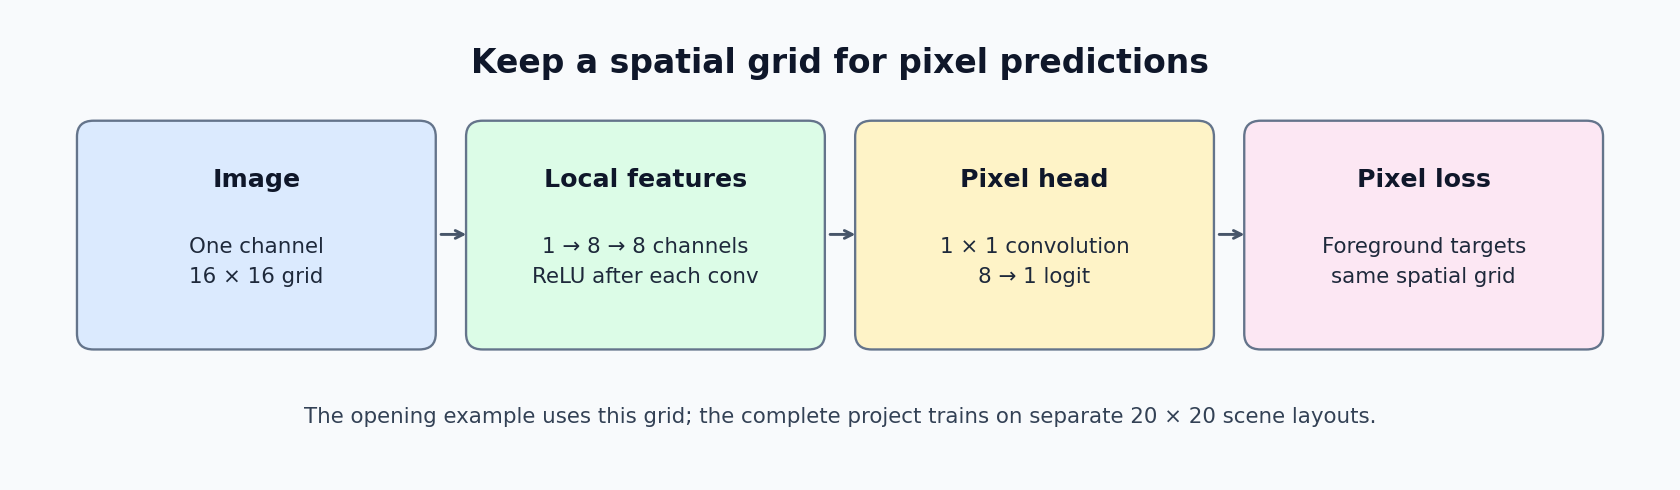

The generated batch contains 64 one-channel $16\times16$ images. The target masks have the same shape. Each image is its rectangle mask plus Gaussian noise scaled by 0.05.

| Stage | Shape | Parameters |
| --- | --- | --- |
| Input | $(64,1,16,16)$ | None |
| Conv $1\to8$, $3\times3$, padding 1 | $(64,8,16,16)$ | 80 |
| ReLU | $(64,8,16,16)$ | None |
| Conv $8\to8$, $3\times3$, padding 1 | $(64,8,16,16)$ | 584 |
| ReLU | $(64,8,16,16)$ | None |
| Conv $8\to1$, $1\times1$ | $(64,1,16,16)$ | 9 |

The model totals 673 learned parameters. A valid-position output from its two spatial convolutions has nominal receptive-field width five before considering borders. The pixel head mixes feature channels without collapsing the spatial axes.

Unlike a global-average classifier, this network retains a prediction at every stored pixel. The output shape must match the masks, but matching shapes alone does not prove label alignment or useful segmentation.


## Interpret the threshold and the one-update result

The companion computes binary cross-entropy on the raw logits, takes one Adam step at learning rate 0.01, then thresholds new logits at zero. Because sigmoid is increasing, `logit > 0` corresponds to probability greater than 0.5.

It accumulates intersection and union over all training pixels and prints their ratio. This is a global foreground IoU on the same examples used for the update, not a mean per-image IoU or a held-out score.

The rectangle locations and dimensions follow an index-based repeating pattern; new noise is added, but the geometry is not an unrestricted collection of shapes. That opening example has no validation or test split; the complete project below adds both.

A pixel-intensity threshold at 0.5 is a strong baseline for this generator because the image is almost directly the target mask plus small noise. Learning a CNN on it demonstrates the dense-output interface rather than proving that complex spatial recognition was necessary.

To assess learning, use more than one update, independent held-out examples, and a task whose output cannot be recovered by the obvious baseline alone.


## Preserve label geometry during transformations

Image resizing, cropping, and flipping must keep boxes, masks, and keypoints aligned with the transformed input. A transform applied only to the image silently creates incorrect supervision.

| Transform | Label action |
| --- | --- |
| Resize | Scale box/keypoint coordinates and resize mask geometry |
| Horizontal flip | Reflect coordinates and mask columns |
| Crop | Shift coordinates, clip regions, and handle removed objects |
| Padding | Track valid pixels and coordinate offsets |

Class-ID masks should use a label-preserving resizing rule rather than interpolation that invents fractional category IDs. Continuous target maps, such as some heatmaps, can have a different rule because their values mean something else.

For pixel losses, track whether an area is known background or simply unlabeled. For detection, an object cut by a crop may need adjusted extent, exclusion, or a partial-object policy. Define that behavior as part of the dataset contract.

Inspect transformed input/label pairs together before training. A valid tensor shape cannot reveal that a mask was flipped independently from its image.


## Represent and evaluate keypoints explicitly

A keypoint model may predict $(x,y)$ coordinates directly or output a spatial heatmap for each landmark. Heatmaps retain uncertainty over location, while coordinates supply a compact point output; either needs a defined conversion and loss.

If the target is $(2,3)$ and prediction is $(5,7)$, the Euclidean error is $\sqrt{(5-2)^2+(7-3)^2}=5$ pixels. Normalized metrics may divide by a reference extent, so the normalization convention changes the meaning of the score.

| Detail | Why it matters |
| --- | --- |
| Landmark visibility | Hidden or unlabeled points may need ignored loss |
| Coordinate units | Pixels and normalized coordinates differ |
| Resize/crop mapping | Predicted and target coordinates must share a frame |
| Heatmap resolution | Coarse grid cells map to input locations |

A class score cannot answer a landmark question, and a box center is not automatically a valid landmark. The output's semantics must come from explicit labels and a matching objective.


## Build evaluation around the deployment question

For real dense-prediction data, split by the independent source when images are related: scene, video, object, person, acquisition session, or another unit appropriate to the task. Nearby video frames in both training and test can make performance appear better than it is on a new scene.

| Task | Evaluate | Inspect errors by |
| --- | --- | --- |
| Detection | Matching and ranked precision/recall | Class, object size, overlap |
| Semantic masks | Per-class overlap and boundary behavior | Class, area, source |
| Instances | Correct object masks and matching | Crowding and occlusion |
| Keypoints | Location error under a stated protocol | Visibility and landmark type |

Choose model settings and thresholds using validation before a final test assessment. Include a baseline that uses the same available input and label information. State whether a score averages images equally or weights all valid pixels equally.

A useful assessment asks whether the output solves the localization problem across representative variation, rather than only whether a loss becomes finite or a colorful mask looks plausible.


## Diagnose output-contract mistakes

| Symptom | First check |
| --- | --- |
| Good pixel accuracy, empty predicted objects | Background imbalance and foreground overlap |
| Masks shift relative to images | Resize, crop, and alignment rules |
| Detector counts one object several times | Matching and duplicate predictions |
| Classifier used where locations are required | Head and target format |
| Loss decreases, thresholded masks do not improve | Probability calibration and chosen threshold |
| Shape match but wrong labels | Coordinate frame and class-ID mapping |

The opening example checks finite loss and matching output/target shapes after one update. The second project trains on 320 scenes, selects on 80 validation scenes, restores the selected checkpoint, and reports IoU and Dice on 80 test scenes with excluded layouts.


## Practice the locations and retain the question

1. With $TP=6$, $FP=2$, and $FN=2$, what is foreground IoU?
2. Does semantic segmentation automatically distinguish two touching objects of the same class?
3. What probability threshold corresponds to logit zero?
4. How many parameters are in the companion's dense model?
5. Is its printed IoU a held-out evaluation?

**Answers.** IoU is $6/(6+2+2)=0.6$. Semantic class labels alone do not identify separate instances. Logit zero corresponds to probability 0.5. The model has 673 parameters. The printed IoU uses the training examples after one update.

**Remember:** classification, boxes, semantic pixels, instances, and landmarks answer different questions. Preserve the required spatial structure, align labels with inputs, and choose a loss and metric that assess the intended output.

Continue with [Generative Modeling Foundations](37_Generative_Modeling_Foundations_Notes.ipynb), which changes the goal from predicting labels or locations to sampling new observations.


## Complete project walkthrough: train and evaluate a segmenter

<div style="background:#DCFCE7;border-left:6px solid #16A34A;padding:16px;border-radius:8px"><b>A complete experiment follows the one-update demonstration.</b> The second project trains a separate CNN, restores the best validation checkpoint, evaluates excluded layouts, and displays inputs, ground-truth masks, and predictions.</div>

We enumerate rectangle/ellipse templates by shape, position, height, and width. A seeded shuffle selects 480 unique layouts and partitions them before image generation. Random background, contrast, texture, and Gaussian noise create the observed images. Each image has one known foreground mask. Layout-set assertions prevent the same geometric template from crossing partitions.

| Partition | Scenes | Shape | Purpose |
|---|---|---|---|
| Training | 320 | `[320,1,20,20]` | Parameter updates |
| Validation | 80 | `[80,1,20,20]` | Checkpoint selection |
| Test | 80 | `[80,1,20,20]` | Final excluded-layout assessment |

The model applies `1→8→16→8` padded 3×3 convolutions with ReLU, then an `8→1` 1×1 head. It preserves a 20×20 prediction grid and has 2,417 parameters. This is a same-resolution CNN, not a U-Net; its purpose is a fully inspectable foreground experiment.


### Training protocol and denominator choices

Adam uses learning rate 0.003. Forty epochs with ten batches of 32 yield 400 updates. Validation BCE is computed after each epoch without gradients. The saved state is a deep copy, and the selected checkpoint is restored before test measurement. Probability threshold 0.5 is fixed beforehand, corresponding to logit zero.

| Metric | Calculation | Weighting |
|---|---|---|
| Pixel accuracy | Correct labels / all pixels | Foreground and background alike |
| Global IoU | Sum intersections / sum unions | Larger unions contribute more |
| Mean image IoU | Average per-image overlap | Every scene contributes equally |
| Mean image Dice | Average $2I/(P+Y)$ | Every scene contributes equally |
| BCE | Mean target log loss | Uses probabilities, not just thresholded masks |

The metric implementation explicitly gives empty/empty masks overlap 1; current scenes always contain foreground. A separate hand-check with one true positive, one false positive, and one false negative gives IoU 1/3 and Dice 1/2.


### Why a background baseline belongs here

Predicting background everywhere can produce high pixel accuracy because most pixels are background. It has zero foreground IoU and Dice on these nonempty objects. Compare this baseline with the CNN on the identical test images, then inspect several masks for boundary mistakes. Curves use training minibatch means and validation full-set BCE; their measurement timing differs slightly.

The test set contains excluded templates drawn from the same simple generator. Success supports this controlled task, not photographic segmentation, multiple-object separation, or robustness to unfamiliar shapes. Test plots describe results after selection rather than drive further tuning.


## Executed reference run: Foreground segmentation

<div style="background:#DCFCE7;border-left:6px solid #16A34A;padding:14px;border-radius:8px"><b>Measured results.</b> Selected epoch: 40. Test BCE: **0.0056**, global foreground IoU: **0.9784**, mean image IoU: **0.9764**, mean image Dice: **0.9877**. Background-only pixel accuracy: 0.9128, but foreground IoU and Dice are both zero.</div>

These outputs were obtained by running every code cell in a fresh CPU kernel with the repository’s virtual environment. They describe this fixed synthetic experiment, not performance on arbitrary real-world data.

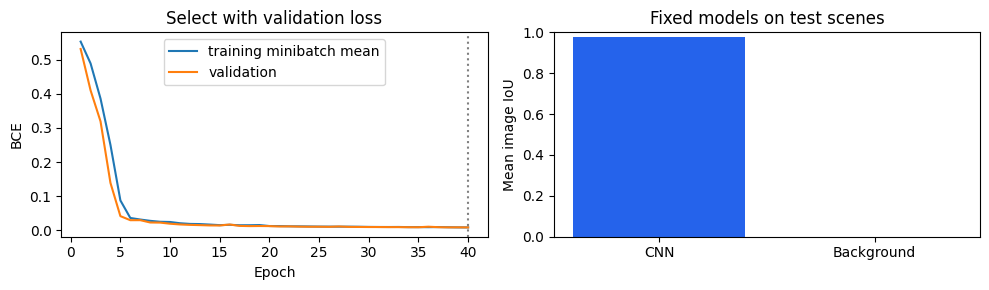

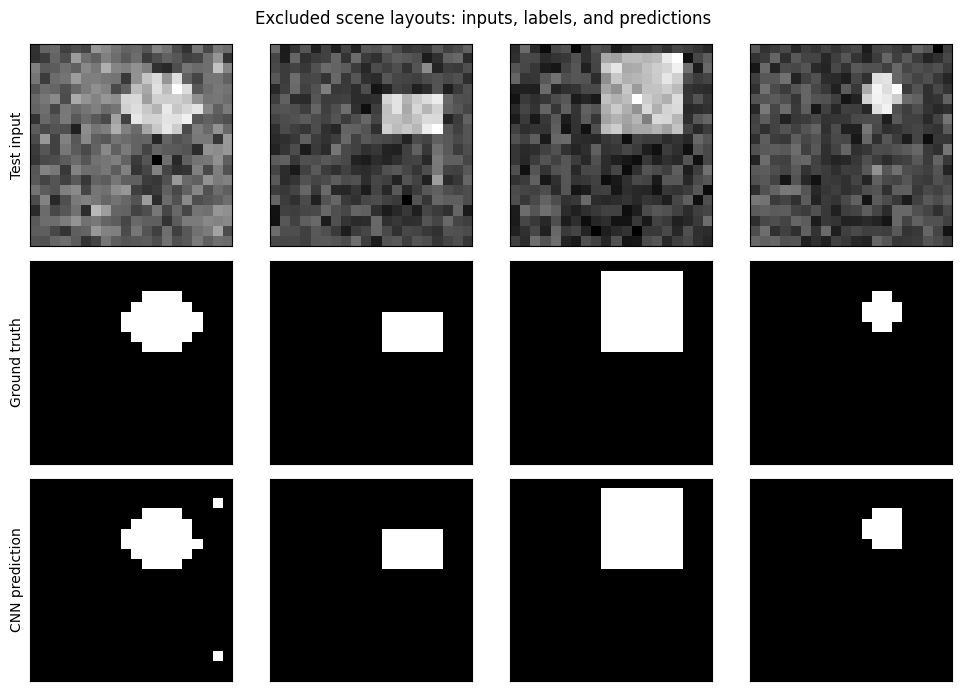
